In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [2]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

2026-03-13 05:32:36.502492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773379956.688889      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773379956.745191      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773379957.182413      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773379957.182457      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773379957.182460      55 computation_placer.cc:177] computation placer alr

In [3]:
import os
os.listdir("/kaggle/input")

['datasets']

In [4]:
import os
os.listdir("/kaggle/input/datasets")

['paultimothymooney']

In [5]:
import os
os.listdir("/kaggle/input/datasets/paultimothymooney")

['chest-xray-pneumonia']

In [6]:
os.listdir("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia")

['chest_xray']

In [7]:
data_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    data_dir + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    data_dir + "/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    data_dir + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [21]:
for layer in base_model.layers:
    layer.trainable = False

In [22]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 764ms/step - accuracy: 0.8301 - loss: 0.3605 - val_accuracy: 0.8111 - val_loss: 0.3759
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 694ms/step - accuracy: 0.8507 - loss: 0.3392 - val_accuracy: 0.8408 - val_loss: 0.3503
Epoch 3/20
114/131 ━━━━━━━━━━━━━━━━━━━━ 9s 552ms/step - accuracy: 0.8351 - loss: 0.3444

In [24]:
model.save("pneumonia_resnet50.keras")

In [25]:
import os
os.listdir("/kaggle/working")

['pneumonia_resnet50.keras', '.virtual_documents', 'pneumonia_resnet50.h5']

In [26]:
from tensorflow.keras.models import load_model

model = load_model("pneumonia_resnet50.keras")

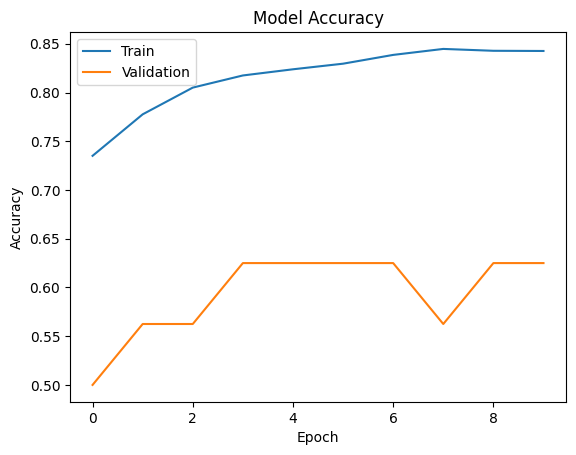

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [29]:
import os

os.listdir("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA")[:10]

['person1676_virus_2892.jpeg',
 'person1650_virus_2852.jpeg',
 'person22_virus_55.jpeg',
 'person122_bacteria_582.jpeg',
 'person85_bacteria_417.jpeg',
 'person79_virus_148.jpeg',
 'person29_virus_64.jpeg',
 'person123_bacteria_587.jpeg',
 'person75_virus_136.jpeg',
 'person153_bacteria_725.jpeg']

In [31]:
img_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg"

In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img = image.img_to_array(img) / 255
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
PNEUMONIA DETECTED


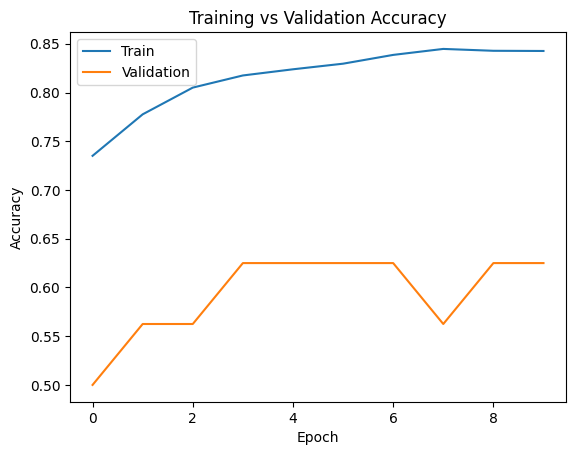

In [33]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

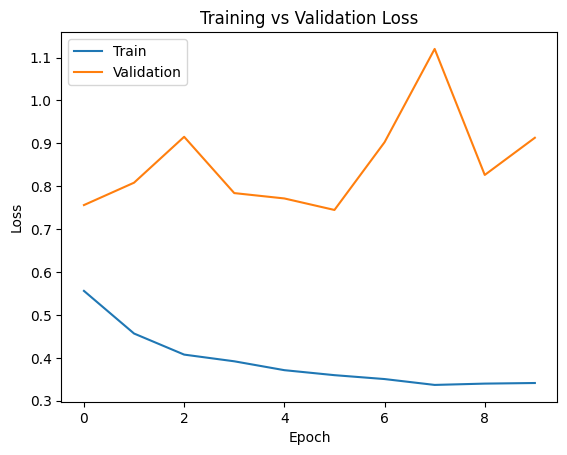

In [34]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    data_dir + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

test_generator.reset()

pred = model.predict(test_generator)
pred_classes = (pred > 0.5).astype(int)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 626ms/step
[[191  43]
 [ 60 330]]


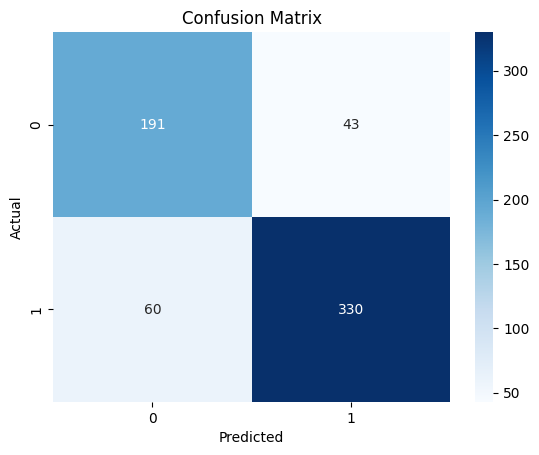

In [38]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


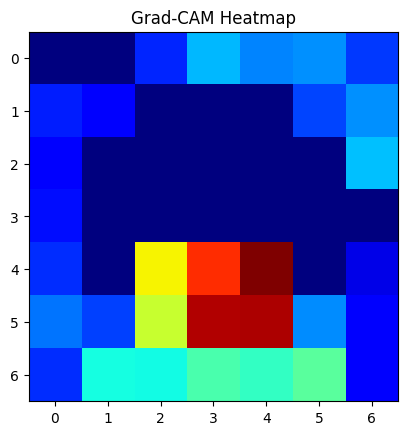

In [39]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255

grad_model = tf.keras.models.Model(
    [model.inputs], 
    [model.get_layer("conv5_block3_out").output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:,0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.show()

In [40]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.0 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [41]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("pneumonia_resnet50.keras")

st.title("Pneumonia Detection using AI")

uploaded_file = st.file_uploader("Upload Chest X-ray", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded X-ray")

    img = img.resize((224,224))
    img = np.array(img)/255
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        st.error("PNEUMONIA DETECTED")
    else:
        st.success("NORMAL")

2026-03-13 06:32:32.147 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.515 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-13 06:32:32.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.518 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 06:32:32.519 Thread 'MainThread': mi

In [44]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load trained model
model = tf.keras.models.load_model("pneumonia_resnet50.keras")

st.title("Pneumonia Detection using Deep Learning")

uploaded_file = st.file_uploader("Upload Chest X-ray Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded X-ray", use_column_width=True)

    img = img.resize((224,224))
    img = np.array(img)/255
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        st.error("PNEUMONIA DETECTED")
    else:
        st.success("NORMAL")

Writing app.py


In [45]:
import os
os.listdir("/kaggle/working")

['app.py',
 'pneumonia_resnet50.keras',
 '.virtual_documents',
 'pneumonia_resnet50.h5']

In [47]:
pip install streamlit tensorflow pillow numpy

Note: you may need to restart the kernel to use updated packages.


In [49]:
!pip install streamlit pyngrok

In [51]:
!pip install gradio

In [53]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load trained model
model = tf.keras.models.load_model("pneumonia_resnet50.keras")

# Prediction function
def predict_pneumonia(img):

    img = img.resize((224,224))
    img = np.array(img)/255
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        return "PNEUMONIA DETECTED"
    else:
        return "NORMAL"


# Gradio UI
interface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Pneumonia Detection using Deep Learning",
    description="Upload a Chest X-ray image to detect Pneumonia"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://8676dbef25b257f971.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
